In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import randint
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from utils import get_classifier_metrics
import pickle
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

# Clasificador de Vinos con KNN

## Carga del conjunto de datos

> **¿Podría una IA ayudarte a elegir un vino digno de sommelier?**

La columna objetivo es label:

0 = Baja calidad   
1 = Calidad media   
2 = Alta calidad

In [2]:
df = pd.read_csv('../data/raw/winequality-red.csv', sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.shape

(1599, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


## Limpieza de datos

In [6]:
df.duplicated()

0       False
1       False
2       False
3       False
4        True
        ...  
1594    False
1595    False
1596     True
1597    False
1598    False
Length: 1599, dtype: bool

In [7]:
df.duplicated().sum()

np.int64(240)

In [8]:
# To show all the duplicated raws 
duplicated = df[df.duplicated(keep=False)]
duplicated

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
9,7.5,0.500,0.36,6.1,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
11,7.5,0.500,0.36,6.1,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
22,7.9,0.430,0.21,1.6,0.106,10.0,37.0,0.99660,3.17,0.91,9.5,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1567,7.2,0.695,0.13,2.0,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1579,6.2,0.560,0.09,1.7,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5
1581,6.2,0.560,0.09,1.7,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5
1592,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6


In [9]:
# To modify deleting duplicated ones and create a new copy of data frame
df.drop_duplicates(inplace=True)

In [10]:
df.shape

(1359, 12)

In [11]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [12]:
df[(df == 0).any(axis=1)]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.0,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.0,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
5,7.4,0.660,0.0,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5
7,7.3,0.650,0.0,1.2,0.065,15.0,21.0,0.99460,3.39,0.47,10.0,7
12,5.6,0.615,0.0,1.6,0.089,16.0,59.0,0.99430,3.58,0.52,9.9,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1455,6.5,0.900,0.0,1.6,0.052,9.0,17.0,0.99467,3.50,0.63,10.9,6
1461,6.2,0.785,0.0,2.1,0.060,6.0,13.0,0.99664,3.59,0.61,10.0,4
1550,7.1,0.680,0.0,2.3,0.087,17.0,26.0,0.99783,3.45,0.53,9.5,5
1551,7.1,0.670,0.0,2.3,0.083,18.0,27.0,0.99768,3.44,0.54,9.4,5


Es totalmente posible que un vino tinto tenga un valor de ácido cítrico igual a 0; por lo tanto, nos quedaremos con los valores de 0.   
Para conocer mejor nuestros datos, hacemos un par de gráficos diferentes.

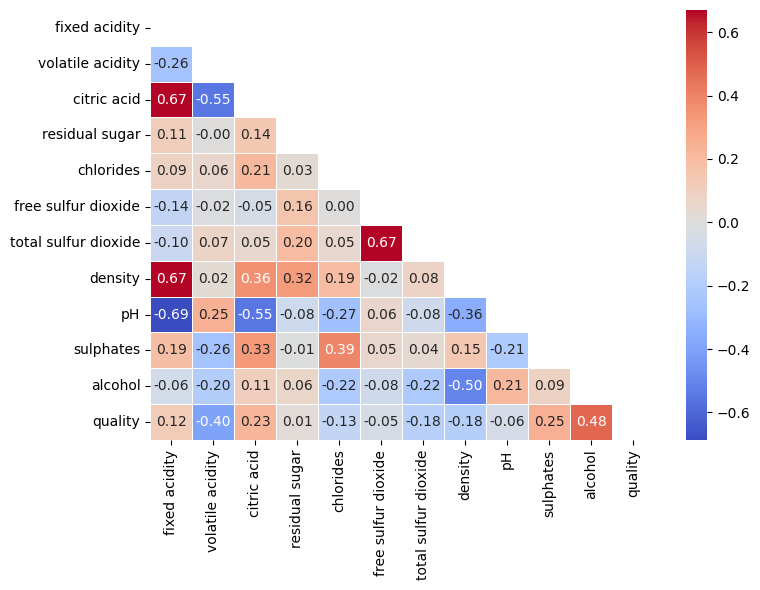

In [13]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, mask=mask, linewidths=0.5, fmt=".2f", cmap='coolwarm')

plt.tight_layout()
plt.show()

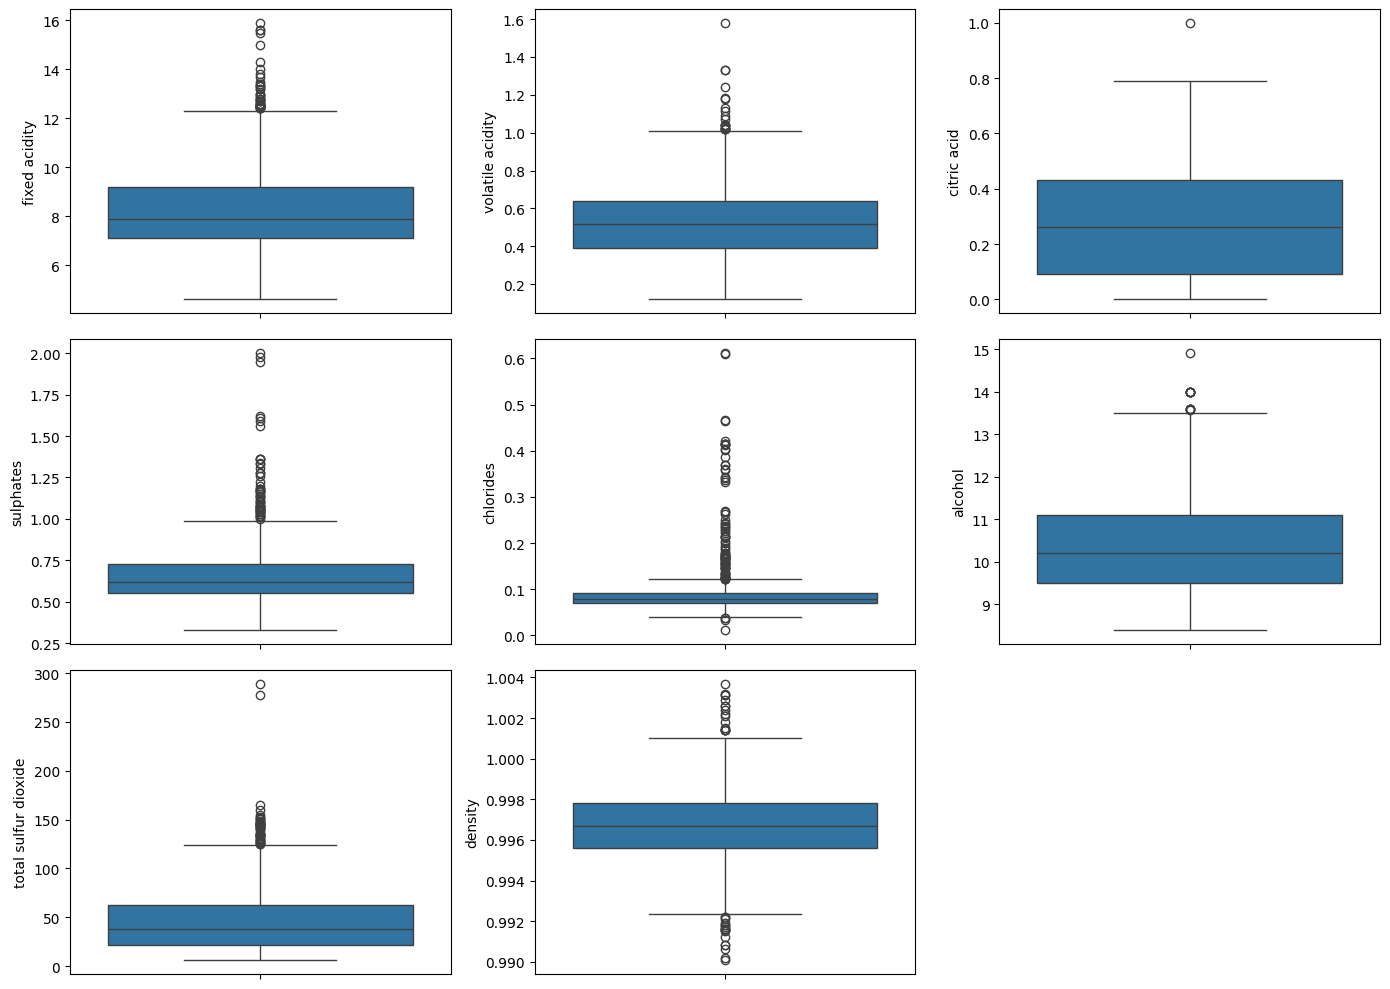

In [14]:
fig, axis = plt.subplots(3, 3, figsize=(14, 10))

sns.boxplot(ax=axis[0, 0], data=df, y='fixed acidity')
sns.boxplot(ax=axis[0, 1], data=df, y='volatile acidity')
sns.boxplot(ax=axis[0, 2], data=df, y='citric acid')
sns.boxplot(ax=axis[1, 0], data=df, y='sulphates')
sns.boxplot(ax=axis[1, 1], data=df, y='chlorides')
sns.boxplot(ax=axis[1, 2], data=df, y='alcohol')
sns.boxplot(ax=axis[2, 0], data=df, y='total sulfur dioxide')
sns.boxplot(ax=axis[2, 1], data=df, y='density')

fig.delaxes(axis[2, 2])
plt.tight_layout()
plt.show()

#### Observaciones:

Viendo los gráficos, podemos decir que los outliers en este caso corresponden a datos relevantes, porque los vinos pueden tener valores muy bajos o muy altos dependiendo de otros factores. Por ejemplo, tenemos un valor de 16 en alcohol, pero eso no significa que un vino no pueda ser tan fuerte o que no pueda tener mucha acidez.

In [15]:
# Target 
mapping = {3: 0,
           4: 0,
           5: 1, 
           6: 1, 
           7: 2,
           8: 2}

df['quality'] = df['quality'].map(mapping)

In [16]:
df['quality']

0       1
1       1
2       1
3       1
5       1
       ..
1593    1
1594    1
1595    1
1597    1
1598    1
Name: quality, Length: 1359, dtype: int64

In [17]:
df['quality'].value_counts()

quality
1    1112
2     184
0      63
Name: count, dtype: int64

In [18]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,1
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,1
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,1
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,1
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,1


In [39]:
import plotly.express as px

fig = px.scatter_3d(df,
                    x='alcohol',
                    y='residual sugar',
                    z='sulphates',
                    color='fixed acidity',
                    size=df['density'].abs(),
                    width=1000,
                    height=500,
                    color_continuous_scale=px.colors.sequential.Viridis)

camera = dict(up=dict(x=0, y=0, z=1),
              eye=dict(x=1.5, y=1.5, z=1))

fig.update_layout(scene_camera=camera)
fig.show()

## Split 

In [20]:
X =df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=18)

In [21]:
X_train.shape

(1087, 11)

## Escalado

In [22]:
norm_scaler = StandardScaler()

numerical_variables = X_train.select_dtypes(include=['int64','float64']).columns.tolist()

X_train_scaled_num = norm_scaler.fit_transform(X_train[numerical_variables])
X_test_scaled_num = norm_scaler.transform(X_test[numerical_variables])

X_train_scaled_numerical = pd.DataFrame(X_train_scaled_num, 
                                        index=X_train.index,
                                        columns=numerical_variables)

X_test_scaled_numerical = pd.DataFrame(X_test_scaled_num,
                                       index=X_test.index,
                                       columns=numerical_variables)

In [23]:
X_train_scaled_numerical.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
472,2.469470,-0.886437,1.500319,0.045941,-0.086985,0.897521,0.645904,1.521389,-1.046907,0.977564,-0.041925
25,-1.123678,-0.776580,-0.547494,-0.810134,-0.151118,-0.472093,-0.726185,-0.603816,0.170124,-0.583335,-1.044865
691,0.556988,2.134635,-0.127430,0.045941,-0.001475,-0.374263,1.408176,1.680780,1.066884,-0.703404,-0.588983
240,0.383126,0.569170,0.555175,-0.596116,3.760980,-1.059070,0.462959,0.246266,-2.007721,2.598498,-1.044865
1218,-0.022552,-0.721651,0.240126,-0.453436,-0.108363,-0.765582,-0.695694,-0.338166,-0.470419,0.197114,0.140427


In [24]:
y_train.head()

472     1
25      1
691     1
240     1
1218    1
Name: quality, dtype: int64

In [25]:
X_train_final = X_train_scaled_numerical
X_test_final = X_test_scaled_numerical 

## Entrenar KNN 

In [26]:
model = KNeighborsClassifier()
model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [27]:
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

y_pred_test

array([1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1])

In [28]:
# Accuracy_score
accuracy = {'Accuracy Test': accuracy_score(y_test, y_pred_test),
            'Accuracy Train': accuracy_score(y_train, y_pred_train)}
accuracy

{'Accuracy Test': 0.8014705882352942, 'Accuracy Train': 0.8482060717571297}

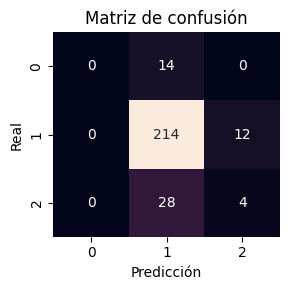

In [29]:
# Confusion matrix
wine_cm = confusion_matrix(y_test, y_pred_test)

cm_df = pd.DataFrame(wine_cm)

plt.figure(figsize=(3,3))
sns.heatmap(cm_df, annot=True, fmt='d', cbar=False)

plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión')
plt.tight_layout()
plt.show()

#### Observaciones:

Al analizar la matriz de confusión del clasificador de vinos (etiquetas 0 = baja calidad, 1 = calidad media, 2 = alta calidad) se observa un claro sesgo hacia la clase 1.
Todos los vinos de baja calidad (clase 0) son sistemáticamente clasificados como calidad media, de modo que el modelo no es capaz de identificar ningún caso de baja calidad (recall de la clase 0 = 0%).

In [30]:
# Classification report
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train)

,Accuracy,F1 Score,Precision,Recall
Train set,0.848206,0.848206,0.848206,0.848206
Test set,0.801471,0.801471,0.801471,0.801471


### Hiperparametrización 

In [31]:
hiper_params = {'n_neighbors': [5, 7, 9, 11, 17, 19, 21, 23, 25, 27, 29, 31],
                'weights': ['uniform', 'distance'],
                'metric': ['euclidean', 'manhattan', 'minkowski', 'chebyshev'],
                'p': [1, 2]}

In [32]:
hiper_params = {'n_neighbors': [5, 7, 9, 11, 17, 19, 21, 23, 25, 27, 29, 31],
                'weights': ['uniform', 'distance'],
                'metric': ['euclidean', 'manhattan', 'minkowski', 'chebyshev'],
                'leaf_size': [10, 20, 30, 40, 50],
                'p': [1, 2]}

In [33]:
hiper_params = {'n_neighbors': [5, 7, 9, 11, 17, 19, 21, 23, 25, 27, 29, 31],
                'weights': ['uniform', 'distance'],
                'leaf_size': [10, 20, 30, 40, 50],
                'p': [1, 2]}

In [34]:
random_search = RandomizedSearchCV(estimator=model,
                                   param_distributions=hiper_params,
                                   n_iter=50,
                                   cv=5,
                                   scoring='accuracy',
                                   random_state=45,
                                   n_jobs=-1)

random_search.fit(X_train, y_train)
random_search.best_params_

{'weights': 'distance', 'p': 2, 'n_neighbors': 19, 'leaf_size': 30}

In [35]:
random_search.best_score_

np.float64(0.8242929015346891)

In [36]:
best_knn = random_search.best_estimator_
best_knn

,n_neighbors,19
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [37]:
y_pred = best_knn.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
test_accuracy

0.8419117647058824

In [38]:
with open('/workspaces/inetke-machine-learning/models/k-nearest-neighbours-winequality.pkl', 'wb') as file:
    pickle.dump(best_knn, file)

### Conclusiones: 

#### Comparación numérica  
**Antes de RandomizedSearchCV (modelo base):**
- Train: Accuracy = 0.8482
- Test: Accuracy = 0.8015  

**Después de RandomizedSearchCV:**
- Train: Accuracy = 0.8243
- Test: Accuracy = 0.8419   

Antes de la optimización de hiperparámetros mediante RandomizedSearchCV, el modelo obtenía una accuracy de 0.8482 en entrenamiento y 0.8015 en el conjunto de prueba.
Tras la búsqueda aleatoria, el mejor conjunto de hiperparámetros alcanzó una accuracy media en validación cruzada de 0.8243, y una accuracy final en el conjunto de test de 0.8419.
Esto supone una mejora de alrededor de 4 puntos porcentuales en el rendimiento sobre datos no vistos respecto al modelo base, manteniendo un nivel de sobreajuste moderado.
En consecuencia, el modelo ajustado mediante RandomizedSearchCV presenta una mejor capacidad de generalización y se considera la versión final recomendada para el problema de clasificación de vinos.
